In [1]:
from tqdm.notebook import tqdm
import torch
import os
import numpy as np
from pathlib import Path

import sys
sys.path.append('../')

from src.data.utils import load_dataset, get_n_classes, load_external_charite
from src.data.dataset import PhysionetDataset
from src.data.preprocess import PreprocessTransform_Merge, PreprocessTransform_Crop, PreprocessTransform_FillZero
from src.models.cnn_model import CNNModel
from src.models.utils import progress
from src.networks.cnn_network import CNNNetwork
from src.networks.resnet import ResNet

from torch.utils.tensorboard import SummaryWriter

import torchvision.transforms as T

from utils.models_mcsharry_ecg_model import integrate

import matplotlib.pyplot as plt

# This should be 4, but windows only allows a single dataloader
DATALOADER_WORKER = 0

N_TRAIN = 512
N_TEST = 64
GAUSSIAN_NOISE_VARIANCE=1e-3


In [2]:
base_path = Path('../data/sim/')

input_path = base_path.joinpath('train')
input_path_test = base_path.joinpath('test')

if not os.path.exists(input_path):
    os.makedirs(input_path)
    
if not os.path.exists(input_path_test):
    os.makedirs(input_path_test)

output_path = base_path.joinpath('output_directory')

print(input_path.absolute())

/home/felix/Repos/physionet2020/notebooks/../data/sim/train


In [ ]:
# Create training and test data with two classes
# Class 0: with P peaks
# Class 1: wo P peaks
a_consts_0 = np.array([1.2, -5.0, 30.0, -7.5, 0.75])
a_consts_1 = np.array([0, -5.0, 30.0, -7.5, 0.75])

# Create trainig data
for i in range(N_TRAIN):
    Ad = integrate(omega=2*np.pi+(np.random.random()-0.5), a_consts=a_consts_0)
    np.save(str(input_path)+'/A'+'{:04d}'.format(i)+'_data.npy', Ad[:, -1:].T)
    np.save(str(input_path)+'/A'+'{:04d}'.format(i)+'_label.npy', np.array(0))
for i in range(N_TRAIN, int(2*N_TRAIN)):
    Ad = integrate(omega=2*np.pi+(np.random.random()-0.5), a_consts=a_consts_1)
    np.save(str(input_path)+'/A'+'{:04d}'.format(i)+'_data.npy', Ad[:, -1:].T)
    np.save(str(input_path)+'/A'+'{:04d}'.format(i)+'_label.npy', np.array(1))
    
# Create test data
for i in range(N_TEST):
    Ad = integrate(omega=2*np.pi+(np.random.random()-0.5), a_consts=a_consts_0)
    np.save(str(input_path_test)+'/A'+'{:04d}'.format(i)+'_data.npy', Ad[:, -1:].T)
    np.save(str(input_path_test)+'/A'+'{:04d}'.format(i)+'_label.npy', np.array(0))
for i in range(N_TEST, int(2*N_TEST)):
    Ad = integrate(omega=2*np.pi+(np.random.random()-0.5), a_consts=a_consts_1)
    np.save(str(input_path_test)+'/A'+'{:04d}'.format(i)+'_data.npy', Ad[:, -1:].T)
    np.save(str(input_path_test)+'/A'+'{:04d}'.format(i)+'_label.npy', np.array(1))

In [ ]:
fig = plt.figure(figsize=(15,3))
ax = fig.add_subplot(111)
ax.plot(Ad[:, -1:]+GAUSSIAN_NOISE_VARIANCE*np.random.randn(*Ad[:, -1:].shape))

In [3]:
x_train, y_train = load_external_charite('train', path=Path('../data/sim'))
x_test, y_test = load_external_charite('test', path=Path('../data/sim'))
print(np.array(x_train).shape)
print(len(x_test))

2048it [00:00, 4498.82it/s]
256it [00:00, 4430.36it/s]

(1024, 1, 5000)
128


In [5]:
writer = SummaryWriter('runs/mainsimple/resnet_lr0002')

# Add Gaussian noise and mean shift
gaussian_noise = T.Compose([T.Lambda(lambda x : x + GAUSSIAN_NOISE_VARIANCE*np.random.randn(*x.shape)+
                                     np.random.randn())])

dataset_train = PhysionetDataset(x_train, y_train, augment_transforms=[gaussian_noise])
dataset_val = PhysionetDataset(x_test, y_test)

dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=64, shuffle=True,
                                                num_workers=DATALOADER_WORKER, pin_memory=True)
dataloader_val = torch.utils.data.DataLoader(dataset_val, batch_size=100, shuffle=False,
                                                num_workers=DATALOADER_WORKER, pin_memory=True)

# network = ResNet(n_length=5000, n_channels=1, n_classes=2)
network = CNNNetwork(n_length=5000, n_channels=1, n_classes=2)
model = CNNModel(dataloader_train, dataloader_val, Path('./'), network, n_classes=2, learning_rate=0.0002, class_weighting=False)

epochs = 250
t = tqdm(range(0, epochs), total=epochs, leave=True, desc=progress(0, 0, 0, 0))

train_loss_list = []
val_loss_list = []
for epoch in t:
    train_accu, train_loss = model.train(epoch)
    val_accu, val_loss = model.validate(epoch)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    t.set_description(progress(train_accu, train_loss, val_accu, val_loss))

    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('Loss/val', val_loss, epoch)
    writer.add_scalar('Accuracy/train', train_accu, epoch)
    writer.add_scalar('Accuracy/val', val_accu, epoch)


Input Length Linear: 56
Using: cuda


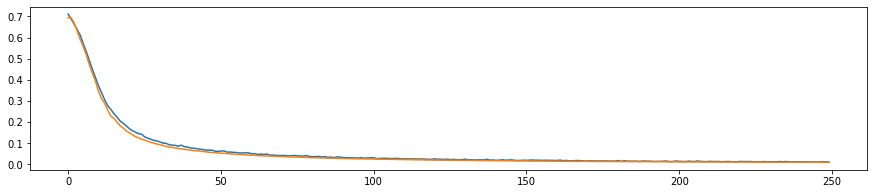

In [6]:
fig = plt.figure(figsize=(15,3))
ax = fig.add_subplot(111)
ax.plot(train_loss_list)
ax.plot(val_loss_list)

In [13]:
model.optimizer.param_groups[0]['lr']

0.0002

In [8]:
model.optimizer.lr

AttributeError: 'SGD' object has no attribute 'lr'